In [225]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [226]:
torch.manual_seed(42)

device = torch.device("mps")
device

device(type='mps')

In [227]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


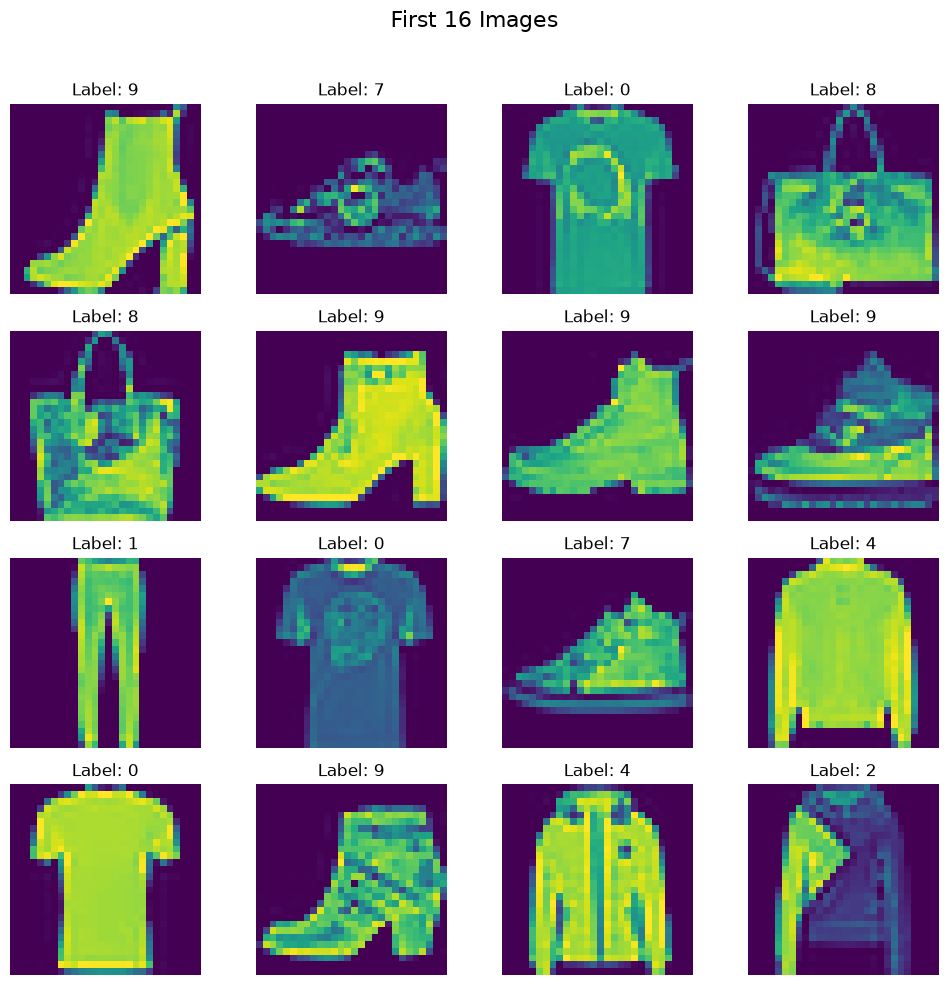

In [228]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i, 0]}") # show the label

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [229]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [230]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [231]:
# scalling the features
X_train = X_train/255.0
X_test = X_test/255.0

X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]], shape=(4800, 784))

In [232]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):

        return self.features[index], self.labels[index]
        

In [233]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [234]:
len(train_dataset)

4800

In [235]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory= True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory= True)

In [236]:
class SimpleRNN(nn.Module):

    def __init__(self, num_features):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        return self.model(x)

In [237]:
# set learning and ecpoch

epochs = 100
learning_rate = 0.1


In [238]:
#instatiate the model
model = SimpleRNN(X_train.shape[1])
model.to(device)

#loss function
criterion = nn.CrossEntropyLoss()

#optimizer
optimizer = optim.SGD(model.parameters(), lr= learning_rate)


In [239]:
#traning loop
for epochs in range(epochs):
    totla_epochs_loss = 0
    for batch_features, batch_lables in train_loader:

        batch_features, batch_lables = batch_features.to(device), batch_lables.to(device)

        # inilalized the model
        outputs = model(batch_features)

        # calcualte loss
        loss = criterion(outputs, batch_lables)

        # no gradation calucalation
        optimizer.zero_grad()

        # calculate the derviative
        loss.backward()
        
        # update the paramaters
        optimizer.step()

        totla_epochs_loss = totla_epochs_loss + loss.item()
    avgerage_loss = totla_epochs_loss / len(train_loader)

    print(f'Epoch: {epochs + 1}, Loss: {avgerage_loss}')


/Users/bikaschaudharytharu/python/pytorch/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch: 1, Loss: 1.321636829773585
Epoch: 2, Loss: 0.7793365097045899
Epoch: 3, Loss: 0.6427524489164352
Epoch: 4, Loss: 0.5751657358805339
Epoch: 5, Loss: 0.5281801925102869
Epoch: 6, Loss: 0.4952874915798505
Epoch: 7, Loss: 0.4602432941397031
Epoch: 8, Loss: 0.43594590509931247
Epoch: 9, Loss: 0.41829214106003443
Epoch: 10, Loss: 0.39840923830866815
Epoch: 11, Loss: 0.38428616205851235
Epoch: 12, Loss: 0.37267840653657913
Epoch: 13, Loss: 0.34853310267130533
Epoch: 14, Loss: 0.3483090657989184
Epoch: 15, Loss: 0.3157504085699717
Epoch: 16, Loss: 0.3099977719783783
Epoch: 17, Loss: 0.2932143503924211
Epoch: 18, Loss: 0.28739641393224397
Epoch: 19, Loss: 0.269316977361838
Epoch: 20, Loss: 0.26488991687695185
Epoch: 21, Loss: 0.2694111023346583
Epoch: 22, Loss: 0.2416099792222182
Epoch: 23, Loss: 0.23942680795987448
Epoch: 24, Loss: 0.22330669251581034
Epoch: 25, Loss: 0.22642606653273106
Epoch: 26, Loss: 0.2092979102830092
Epoch: 27, Loss: 0.21829658702015878
Epoch: 28, Loss: 0.21153506

In [240]:
#set model to eval mode
model.eval()

SimpleRNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [241]:
#evaluation code

total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        output = model(batch_features)

        _,predicted = torch.max(output, 1)

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)


0.835
